# Final Proje — Abstract ile Dergi Önerisi ve Topic Clustering Örnekleri

**Muharrem Kocabıyık** · Bilgisayar Mühendisliği

Bu notebook ödev kapsamında:
1. **Örnek abstract** metinleriyle **Top-5 dergi** tahmini (`journal_recommender_pipeline.pkl`),
2. **KMeans topic kümeleri** (`step9_clustered_dataset.csv`) — küme etiketi, örnek dergiler ve kısa metin örnekleri

gösterir. Tam eğitim `step8` / `step9` script’lerinde; arayüz `app.py` (Streamlit).

## Kurulum: proje kökü, model ve küme verisi

Notebook’u **proje kök klasöründe** açın (`final_project`). Gerekli dosyalar: `journal_recommender_pipeline.pkl`, `step9_clustered_dataset.csv`.

In [7]:
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dashboard.recommender_logic import recommend_journals
from dashboard.clusters_meta import infer_cluster_name, get_cluster_keywords
from dashboard.config import PIPELINE_PATH, CLUSTERED_DATA_PATH

print("Kök:", ROOT)

if not PIPELINE_PATH.is_file():
    raise FileNotFoundError(f"Pipeline yok: {PIPELINE_PATH} — önce step8_final_recommender.py çalıştırın.")
if not CLUSTERED_DATA_PATH.is_file():
    raise FileNotFoundError(f"Küme CSV yok: {CLUSTERED_DATA_PATH} — önce step9_topic_clustering.py çalıştırın.")

pipeline = joblib.load(PIPELINE_PATH)
cluster_df = pd.read_csv(CLUSTERED_DATA_PATH)
print("Pipeline yüklendi.")
print("Küme verisi:", cluster_df.shape, "| sütunlar:", list(cluster_df.columns))

Kök: D:\FourthYear_2\3-Introduction_to_Data_Mining\final_project
Pipeline yüklendi.
Küme verisi: (22980, 4) | sütunlar: ['AcademicRecordID', 'JournalName', 'text_rich', 'cluster']


## 1) Abstract → Top-5 dergi önerisi (örnek senaryolar)

Model **çok kanallı TF-IDF + SGD (log-loss)** pipeline’ıdır. Burada yalnızca **abstract** verilir (başlık/keyword/subject boş); Streamlit’te isteğe bağlı alanlar da doldurulabilir.

Aşağıdaki metinler yapay **örnek** abstract’lardır; farklı alt alanları (veri madenciliği, görüntü, biyoenformatik, ağ) kapsamak için seçilmiştir.

In [8]:
SAMPLE_ABSTRACTS = {
    "Veri madenciliği / sınıflandırma": """
We propose a scalable framework for knowledge discovery from large relational and text databases.
Our method combines frequent pattern mining, feature selection, and ensemble classification.
Experiments on benchmark transaction and document collections show improved F1 and AUC compared to baseline decision trees and naive Bayes.
""".strip(),
    "Bilgisayarlı görü / derin öğrenme": """
This paper presents a convolutional neural network architecture for real-time object detection in surveillance video.
We introduce a lightweight backbone and multi-scale feature fusion; results on COCO-style benchmarks demonstrate reduced latency with competitive mean average precision.
""".strip(),
    "Biyoenformatik / genom": """
We develop an algorithm for aligning short reads to a reference genome under noisy sequencing data.
The approach uses probabilistic modeling of base quality scores and improves variant calling sensitivity for exome datasets.
""".strip(),
    "Ağlar / IoT": """
We study routing and energy efficiency in wireless sensor networks with intermittent connectivity.
A distributed clustering protocol is proposed; simulation shows extended network lifetime compared to LEACH-style baselines.
""".strip(),
}

rows = []
for scenario, abstract in SAMPLE_ABSTRACTS.items():
    recs = recommend_journals(pipeline, abstract=abstract, title="", keywords="", subjects="", top_k=5)
    for rank, r in enumerate(recs, start=1):
        rows.append(
            {
                "Senaryo": scenario,
                "Sıra": rank,
                "Dergi": r["journal"],
                "Olasılık": round(r["score"], 6),
            }
        )

rec_table = pd.DataFrame(rows)
display(rec_table)

for scenario, abstract in SAMPLE_ABSTRACTS.items():
    display(Markdown(f"**{scenario}** — abstract (kısaltılmış):"))
    short = abstract.replace("\n", " ")[:320] + ("…" if len(abstract) > 320 else "")
    display(Markdown(f"_{short}_"))

,Senaryo,Sıra,Dergi,Olasılık
0,Veri madenciliği / sınıflandırma,1,VLDB JOURNAL,0.003468
1,Veri madenciliği / sınıflandırma,2,DATA MINING AND KNOWLEDGE DISCOVERY,0.003423
2,Veri madenciliği / sınıflandırma,3,INFORMATION RETRIEVAL,0.003352
3,Veri madenciliği / sınıflandırma,4,INTERNATIONAL JOURNAL ON DOCUMENT ANALYSIS AND...,0.003328
4,Veri madenciliği / sınıflandırma,5,JOURNAL OF INTELLIGENT INFORMATION SYSTEMS,0.003224
5,Bilgisayarlı görü / derin öğrenme,1,JOURNAL OF REAL-TIME IMAGE PROCESSING,0.003509
6,Bilgisayarlı görü / derin öğrenme,2,NEURAL PROCESSING LETTERS,0.003456
7,Bilgisayarlı görü / derin öğrenme,3,MULTIMEDIA SYSTEMS,0.003216
8,Bilgisayarlı görü / derin öğrenme,4,INTERNATIONAL JOURNAL OF PARALLEL PROGRAMMING,0.003150
9,Bilgisayarlı görü / derin öğrenme,5,ACM TRANSACTIONS ON GRAPHICS,0.003119


**Veri madenciliği / sınıflandırma** — abstract (kısaltılmış):

_We propose a scalable framework for knowledge discovery from large relational and text databases. Our method combines frequent pattern mining, feature selection, and ensemble classification. Experiments on benchmark transaction and document collections show improved F1 and AUC compared to baseline decision trees and na…_

**Bilgisayarlı görü / derin öğrenme** — abstract (kısaltılmış):

_This paper presents a convolutional neural network architecture for real-time object detection in surveillance video. We introduce a lightweight backbone and multi-scale feature fusion; results on COCO-style benchmarks demonstrate reduced latency with competitive mean average precision._

**Biyoenformatik / genom** — abstract (kısaltılmış):

_We develop an algorithm for aligning short reads to a reference genome under noisy sequencing data. The approach uses probabilistic modeling of base quality scores and improves variant calling sensitivity for exome datasets._

**Ağlar / IoT** — abstract (kısaltılmış):

_We study routing and energy efficiency in wireless sensor networks with intermittent connectivity. A distributed clustering protocol is proposed; simulation shows extended network lifetime compared to LEACH-style baselines._

## 2) Topic clustering — küme boyutları

Kümeleme **`text_rich`** (başlık+özet+keyword+subject) üzerinde TF-IDF + **KMeans (k=10)** ile yapılmıştır. Arayüzdeki tema isimleri `dashboard/clusters_meta.py` ile eşleştirilmiştir.

,cluster,makale_sayisi
0,0,1038
1,1,8597
2,2,2904
3,3,1345
4,4,1419
5,5,3211
6,6,751
7,7,2342
8,8,669
9,9,704


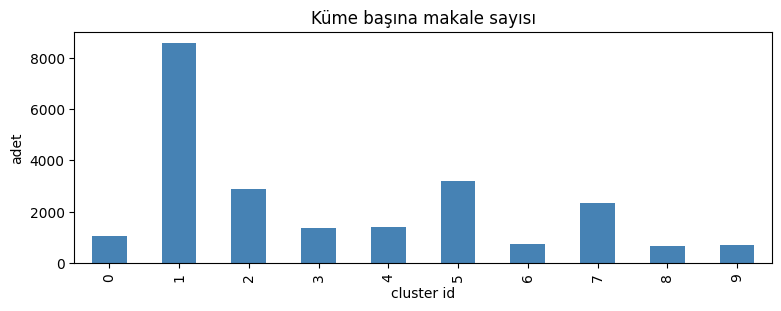

In [9]:
counts = cluster_df["cluster"].value_counts().sort_index()
display(pd.DataFrame({"cluster": counts.index, "makale_sayisi": counts.values}))

ax = counts.plot(kind="bar", figsize=(9, 3), title="Küme başına makale sayısı", color="steelblue")
ax.set_xlabel("cluster id")
ax.set_ylabel("adet")
None

## 3) Her küme için: tema, anahtar kelimeler, örnek dergiler ve metin özeti

Her kümede **en sık 5 dergi** ve rastgele sabit tohumla seçilen **2 makale** için `text_rich` önizlemesi gösterilir.

In [10]:
def cluster_report(cdf: pd.DataFrame, cluster_id: int, n_journals: int = 5, n_samples: int = 2, seed: int = 42):
    sub = cdf[cdf["cluster"] == cluster_id]
    name = infer_cluster_name(cluster_id)
    kws = ", ".join(get_cluster_keywords(cluster_id))
    display(Markdown(f"### Küme `{cluster_id}` — *{name}*"))
    display(Markdown(f"**Örnek anahtar kelimeler (meta):** {kws}"))
    display(Markdown(f"**Makale sayısı:** {len(sub):,}"))

    top_j = sub["JournalName"].value_counts().head(n_journals)
    display(Markdown("**En sık dergiler:**"))
    display(top_j.rename("adet").to_frame())

    samp = sub.sample(min(n_samples, len(sub)), random_state=seed)[["AcademicRecordID", "JournalName", "text_rich"]]
    display(Markdown("**Örnek makaleler (text_rich kısaltılmış):**"))
    preview = (
        samp["text_rich"]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.slice(0, 280)
    )
    out = samp.assign(text_rich_preview=preview + np.where(samp["text_rich"].astype(str).str.len() > 280, "…", ""))
    display(out[["AcademicRecordID", "JournalName", "text_rich_preview"]])
    display(Markdown("---"))


for cid in sorted(cluster_df["cluster"].unique()):
    cluster_report(cluster_df, int(cid))

### Küme `0` — *Cloud Computing and Web Services*

**Örnek anahtar kelimeler (meta):** cloud, service, computing, web, iot

**Makale sayısı:** 1,038

**En sık dergiler:**

,adet
JournalName,
INTERNATIONAL JOURNAL OF WEB SERVICES RESEARCH,35
IEEE TRANSACTIONS ON SERVICES COMPUTING,31
INTERNATIONAL JOURNAL OF WEB AND GRID SERVICES,28
JOURNAL OF NETWORK AND COMPUTER APPLICATIONS,27
JOURNAL OF GRID COMPUTING,22


...

**En sık dergiler:**

,adet
JournalName,
ACM TRANSACTIONS ON SENSOR NETWORKS,46
INTERNATIONAL JOURNAL OF DISTRIBUTED SENSOR NETWORKS,37
INTERNATIONAL JOURNAL OF SENSOR NETWORKS,30
AD HOC & SENSOR WIRELESS NETWORKS,29
WIRELESS NETWORKS,26


**Örnek makaleler (text_rich kısaltılmış):**

,AcademicRecordID,JournalName,text_rich_preview
9573,98894,IEEE TRANSACTIONS ON COMPUTERS,efficient data gathering with mobile collector...
1731,90400,AD HOC NETWORKS,an energy aware distributed clustering protoco...


---

## Not

- Önerileri **sadece abstract** ile ürettik; eğitimde keyword/subject de vardı — gerçek kullanımda Streamlit’te genişletilmiş alanlar daha tutarlı sonuç verebilir.
- Küme isimleri **yorum amaçlı** etiketlerdir; bilimsel tema için `step9` konsolundaki TF-IDF merkez terimlerine de bakın.